In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import librosa.display


In [2]:
df=pd.read_csv("/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv")

In [3]:
df.shape

(8732, 8)

In [4]:
df["classID"].unique()

array([3, 2, 1, 0, 9, 6, 8, 5, 7, 4])

In [5]:
df["class"].unique()

array(['dog_bark', 'children_playing', 'car_horn', 'air_conditioner',
       'street_music', 'gun_shot', 'siren', 'engine_idling', 'jackhammer',
       'drilling'], dtype=object)

# Augmentation

In [6]:
# Time Masking
def augment_time(mel, time_mask=15):
    mel = mel.copy()

    # Time mask
    t = mel.shape[0]
    t_mask = np.random.randint(0, time_mask)
    t0 = np.random.randint(0, t - t_mask)
    mel[t0:t0 + t_mask, :] = 0

    return mel

# Frequency Masking
def augment_freq(mel, freq_mask=15):
    mel = mel.copy()

    # Frequency mask
    f = mel.shape[1]
    f_mask = np.random.randint(0, freq_mask)
    f0 = np.random.randint(0, f - f_mask)
    mel[:, f0:f0 + f_mask] = 0

    return mel

# Data Preparation

In [7]:
sample_rate=22050
duration=4
sample_per_track=sample_rate*duration

N_MELS=128

In [8]:
def process_audio(file_path):
  signal,sr=librosa.load(file_path,sr=sample_rate)

  # Pad or truncate signal to a fixed length (sample_per_track)
  if len(signal) > sample_per_track:
    signal = signal[:sample_per_track]
  elif len(signal) < sample_per_track:
    signal = np.pad(signal, (0, sample_per_track - len(signal)), 'constant')

  
  mel=librosa.feature.melspectrogram(y=signal,sr=sr, n_mels=N_MELS)

  mel_db = librosa.power_to_db(mel, ref=np.max)
  

  return mel_db

In [9]:
x=[]
y=[]


for i,row in df.iterrows():

  file_path=f"/kaggle/input/datasets/chrisfilo/urbansound8k/fold{row['fold']}/{row['slice_file_name']}"

  mel=process_audio(file_path)
  x.append(mel)
  
  y.append(row["classID"])

In [10]:
x=np.array(x)
y=np.array(y)

In [11]:
x.shape

(8732, 128, 173)

In [12]:
y.shape

(8732,)

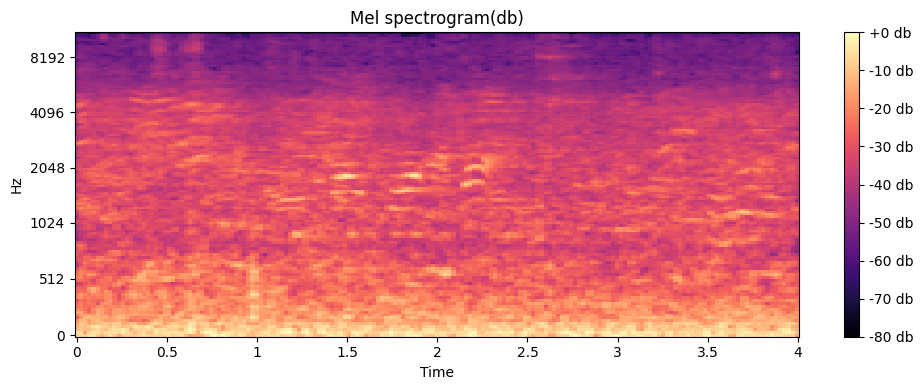

In [13]:
sample=x[6]

plt.figure(figsize=(10,4))
librosa.display.specshow(sample,sr=sample_rate,x_axis="time",y_axis="mel")
plt.colorbar(format="%+2.f db")
plt.title("Mel spectrogram(db)")
plt.tight_layout()
plt.show()

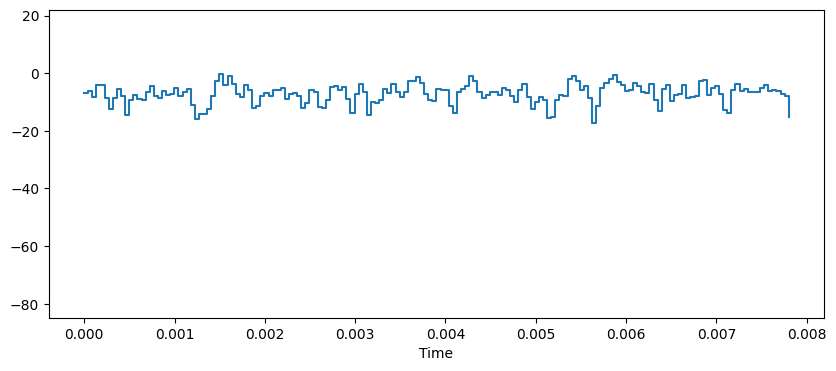

In [14]:
plt.figure(figsize=(10,4))
librosa.display.waveshow(sample)
plt.show()

In [46]:
x = (x - stats["mean"])/(stats["std"] + 1e-8)

In [47]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True,stratify=y)

In [48]:
x_train.shape

(6985, 128, 173)

In [49]:
x_test.shape

(1747, 128, 173)

In [50]:
y_train

array([5, 7, 7, ..., 9, 9, 2])

In [51]:
# #normalise inputs
# x_train = (x_train - x_train.mean())/(x_train.std() + 1e-8)
# x_test = (x_test - x_test.mean())/(x_test.std() + 1e-8)


# Data Augmentation

In [52]:
x_train_aug=[]
y_train_aug = []

for i in range(len(x_train)):
  x_train_aug.append(x_train[i])
  y_train_aug.append(y_train[i])

  x_train_aug.append(augment_freq(augment_time(x_train[i])))
  y_train_aug.append(y_train[i])



x_train_aug = np.array(x_train_aug)
y_train_aug = np.array(y_train_aug)

In [53]:
x_train_aug.shape

(13970, 128, 173)

In [85]:
x_train_for_2D=x_train_aug[...,np.newaxis]
x_test_for_2D=x_test[...,np.newaxis]

In [92]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_aug),
    y=y_train_aug
)
class_weight_dict = dict(enumerate(class_weights))

# ── One-hot for label smoothing ───────────────────────────────────────────────
y_train_oh = to_categorical(y_train_aug, num_classes=10)
y_test_oh  = to_categorical(y_test,        num_classes=10)

# Model Training

In [93]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout,BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [94]:
x_train_for_2D.shape

(13970, 128, 173, 1)

In [95]:
# 2D conv

model=Sequential([
Conv2D(filters=32,kernel_size=(3,3),input_shape=x_train_for_2D.shape[1:],padding="same", activation="relu", kernel_regularizer=l2(1e-4)),                    
BatchNormalization(),              
MaxPool2D(2,2),
Dropout(0.3),
                     
                     
Conv2D(filters=64,kernel_size=(3,3),padding="same", activation="relu",  kernel_regularizer=l2(1e-4)),                    
BatchNormalization(),
MaxPool2D(2,2),
Dropout(0.3),
                     
Conv2D(filters=128,kernel_size=(3,3),padding="same", activation="relu",  kernel_regularizer=l2(1e-4)),       
BatchNormalization(),
MaxPool2D(2,2),
Dropout(0.3),
                     

                     
GlobalAveragePooling2D(),
                    
                     
Dense(128, activation="relu",  kernel_regularizer=l2(1e-4)),                     
BatchNormalization(),
Dropout(0.4),
                     
                     
Dense(10,activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 173, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 173, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 86, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 86, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,882 (437.04 KB)

 Trainable params: 111,178 (434.29 KB)

 Non-trainable params: 704 (2.75 KB)

In [96]:

model.compile(
    optimizer="adam",
    loss=CategoricalCrossentropy(label_smoothing=0.1), # ← stops overconfidence
    metrics=["accuracy"]
)

In [99]:
y_test.shape

(1747,)

In [100]:
history=model.fit(
    x_train_for_2D,
    y_train_oh,
    validation_data=(x_test_for_2D,y_test_oh),
    epochs=60,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor="val_loss",patience=8,restore_best_weights=True)]
)

Epoch 1/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.3045 - loss: 2.1815 - val_accuracy: 0.1706 - val_loss: 5.7454
Epoch 2/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.5593 - loss: 1.5301 - val_accuracy: 0.6085 - val_loss: 1.4712
Epoch 3/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.6942 - loss: 1.2378 - val_accuracy: 0.6938 - val_loss: 1.4183
Epoch 4/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.7587 - loss: 1.1081 - val_accuracy: 0.7149 - val_loss: 1.2526
Epoch 5/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8105 - loss: 1.0162 - val_accuracy: 0.7951 - val_loss: 1.1330
Epoch 6/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8342 - loss: 0.9686 - val_accuracy: 0.8037 - val_loss: 1.0894
Epoch 7/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8564 - loss: 0.9168 - val_accuracy: 0.7945 - val_loss: 1.1293
Epoch 8/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8738 - loss: 0.8838 - 

In [102]:
loss, acc = model.evaluate(x_test_for_2D,y_test_oh)

print(f"test accuracy{acc}, and  test_loss = {loss}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9244 - loss: 0.8156
test accuracy0.926159143447876, and  test_loss = 0.8077521920204163


In [ ]:
import json

# save the model
model.save("Urban_Sound_Model.keras")

#save the normalization satas (as the mean and std should be same as that of used during training)
stats = {
    "mean": float(x.mean()),
    "std": float(x.std())
}

with open("norm_stats.json","w") as f :
    json.dump(stats, f)

print("saved: urban_sound_model.keras and norm_stats.json")

saved: urban_sound_model.keras and norm_stats.json
